# Extended source spectrum

In [1]:
source /export/ciao/bin/ciao.bash -o
PFILES="./param;$ASCDS_INSTALL/param:$ASCDS_INSTALL/contrib/param"
mkdir -p ./param
ASCDS_WORK_PATH=./


CIAO configuration is complete... 
CIAO 4.9 Friday, December  2, 2016
  bindir      : /export/ciao-4.9/bin
  CALDB       : 4.7.3


## Download

In [2]:
/bin/rm -rf 869
download_chandra_obsid 869 


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      10 Kb  ####################          < 1 s  1873.8 kb/s
  oif      fits       25 Kb  ####################          < 1 s  3984.4 kb/s
  vv       pdf        41 Kb  ####################          < 1 s  5335.6 kb/s
  cntr_img fits      177 Kb  ####################          < 1 s  14531.1 kb/s
  cntr_img jpg       815 Kb  ####################          < 1 s  30126.7 kb/s
  evt2     fits       20 Mb  ####################          < 1 s  83799.2 kb/s
  full_img fits       88 Kb  ####################          < 1 s  9692.5 kb/s
  full_img jpg        74 Kb  ####################          < 1 s  8649.6 kb/s
  bpix     fits       38 Kb  ####################          < 1 s  5276.4 kb/s
  fov      fits        6 Kb  ####################          < 1 s  978.4 kb/s
  eph1     fits      281 Kb  ####################          < 

In [3]:
/bin/rm -rf repro
chandra_repro 869 ./repro


Processing input directory '/data/sdsreg/thread_output/CIAO4.9/extended/869'

Resetting afterglow status bits in evt1.fits file...

Running the destreak tool on the evt1.fits file...

Running acis_build_badpix and acis_find_afterglow to create a new bad pixel file...

Running acis_process_events to reprocess the evt1.fits file...
Output from acis_process_events:
# acis_process_events (CIAO 4.9): The following error occurred 81 times:
	dsAPEPULSEHEIGHTERR -- WARNING: pulse height is less than split threshold when performing serial CTI adjustment.
Filtering the evt1.fits file by grade and status and time...
Applying the good time intervals from the flt1.fits file...
The new evt2.fits file is: /data/sdsreg/thread_output/CIAO4.9/extended/repro/acisf00869_repro_evt2.fits

Updating the event file header with chandra_repro HISTORY record
Creating FOV file...
Setting observation-specific bad pixel file in local ardlib.par.

Cleaning up intermediate files

         /data/sdsreg/thread_output/C

## Regions

In [4]:
cat << EOM > simple.reg 
# Region file format: CIAO version 1.0
ellipse(4026,4138.9,50,40,0)
EOM

cat << EOM > simple_bkg.reg
# Region file format: CIAO version 1.0
circle(3955.5,4252.5,50)
EOM


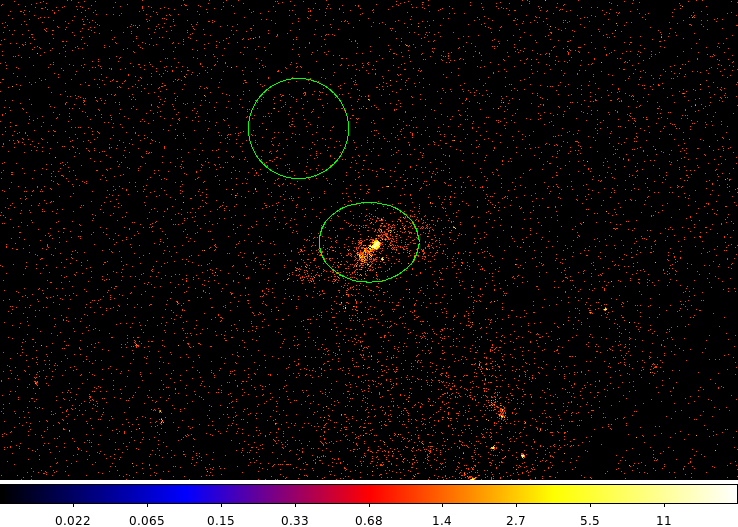

In [5]:
ds9 repro/acisf00869_repro_evt2.fits -bin filter 'energy=500:7000' \
    -bin about 4025 4140 -cmap b -scale log -region simple.reg \
    -region simple_bkg.reg \
    -saveimage png ds9_01.png -quit

display < ds9_01.png

## using `specextract`

In [6]:
pset specextract infile="repro/acisf00869_repro_evt2.fits[sky=region(simple.reg)]"
pset specextract outroot=simple
pset specextract bkgfile="repro/acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)]"
specextract mode=h clob+

Running specextract
Version: 30 November 2016

Checking for blank sky background files...
Using event file repro/acisf00869_repro_evt2.fits[sky=region(simple.reg)]

Aspect solution file repro/pcadf078246822N004_asol1.fits found.

Bad-pixel file repro/acisf00869_repro_bpix1.fits found.

Mask file repro/acisf00869_000N004_msk1.fits found.

Setting bad pixel file 

Extracting src spectra 

Creating src ARF 

Creating src RMF 

Using mkacisrmf...

Grouping src spectrum 

Updating header of simple.pi with RESPFILE and ANCRFILE keywords.

Updating header of simple_grp.pi with RESPFILE and ANCRFILE keywords.

Setting bad pixel file 

Extracting bkg spectra 

Creating bkg ARF 

Creating bkg RMF 

Using mkacisrmf...

Updating header of simple_bkg.pi with RESPFILE and ANCRFILE keywords.

Updating header of simple.pi with BACKFILE keyword.

Updating header of simple_grp.pi with BACKFILE keyword.



---
## Step By Step

### Extract spectra

In [7]:
pset dmextract infile="repro/acisf00869_repro_evt2.fits[sky=region(simple.reg)][bin pi]"
pset dmextract outfile=simple_steps.pi
pset dmextract wmap="[energy=300:2000][bin tdet=8]"
dmextract mode=h clob+ 

In [8]:
pset dmextract infile="repro/acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)][bin pi]"
pset dmextract outfile=simple_steps_bkg.pi
dmextract mode=h clob+

### asphist

In [9]:
cat repro/acisf00869_asol1.lis

/data/sdsreg/thread_output/CIAO4.9/extended/869/primary/pcadf078246822N004_asol1.fits


In [10]:
dmstat "repro/acisf00869_repro_evt2.fits[sky=region(simple.reg)][cols ccd_id]"

ccd_id
    min:	7 	      @:	1 
    max:	7 	      @:	1 
   mean:	7 
  sigma:	0 
    sum:	17738 
   good:	2534 
   null:	0 



In [11]:
dmstat "repro/acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)][cols ccd_id]"

ccd_id
    min:	7 	      @:	1 
    max:	7 	      @:	1 
   mean:	7 
  sigma:	0 
    sum:	10332 
   good:	1476 
   null:	0 



In [12]:
pset asphist infile=@-repro/acisf00869_asol1.lis
pset asphist outfile=simple_steps.asphist
pset asphist evtfile="repro/acisf00869_repro_evt2.fits[ccd_id=7]"
asphist mode=h cl+

In [13]:
dmstat "simple_steps.asphist[cols x_offbin,y_offbin]" sig- med-

POS_OFFBIN(X_OFFBIN, Y_OFFBIN)[bin]
    min:	( 1 1 )	      @:	( 1101 566 )
    max:	( 48 46 )	      @:	( 654 303 )
   mean:	( 24.214814815 23.456790123 )
    sum:	( 29421 28500 )
   good:	( 1215 1215 )
   null:	( 0 0 )



In [14]:
dmcopy simple_steps.asphist"[bin x_offbin=1:50:1,y_offbin=1:50:1;duration]" asphist.img clob+

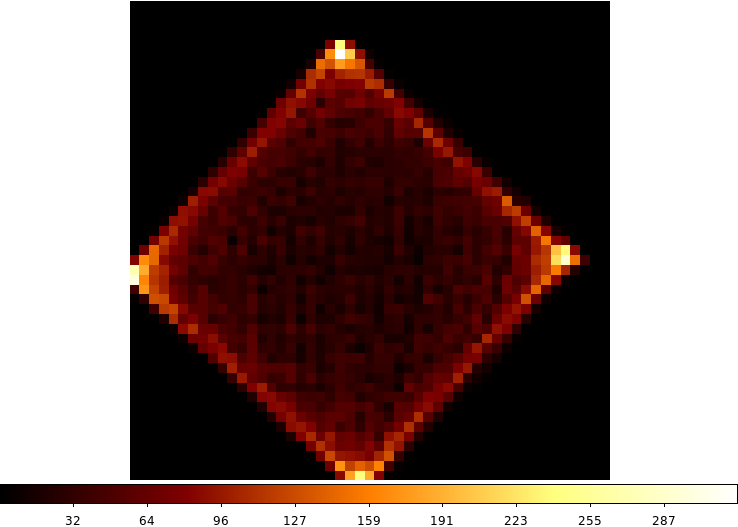

In [15]:
ds9 asphist.img -scale linear -cmap bb \
  -zoom to fit -saveimage png asphist.png -quit
display < asphist.png

### Create WMAPs

In [16]:
pset sky2tdet infile="repro/acisf00869_repro_evt2.fits[sky=region(simple.reg)][energy=300:2000][bin sky=1]"
pset sky2tdet asphistfile="simple_steps.asphist"
pset sky2tdet outfile="simple_steps_tdet.fits[wmap]"
sky2tdet mode=h clob+


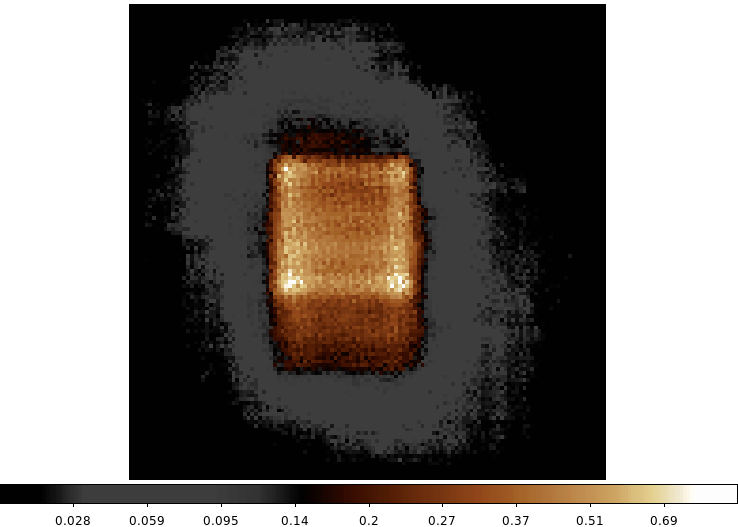

In [17]:
ds9 simple_steps_tdet.fits -scale asinh -zoom to fit -cmap load ${ASCDS_INSTALL}/contrib/data/heart.lut \
  -saveimage png wmap.src.png -quit

display < wmap.src.png

In [18]:
pset sky2tdet infile="repro/acisf00869_repro_evt2.fits[sky=region(simple_bkg.reg)][energy=300:2000][bin sky=1]"
pset sky2tdet outfile="simple_steps_bkg_tdet.fits[wmap]"
sky2tdet mode=h clob+


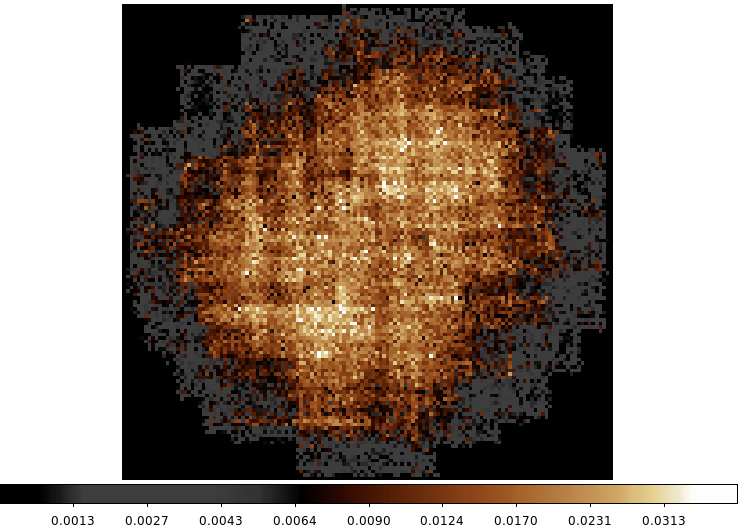

In [19]:
ds9 simple_steps_bkg_tdet.fits -scale asinh -zoom to fit -cmap load ${ASCDS_INSTALL}/contrib/data/heart.lut \
  -saveimage png wmap.bkg.png -quit

display < wmap.bkg.png

### Create ARFs

In [20]:
pset mkwarf infile="simple_steps_tdet.fits[wmap]"
pset mkwarf outfile=simple_steps.arf
pset mkwarf weightfile=simple_steps.wfef
pset mkwarf egridspec=0.3:11.0:0.01 
pset mkwarf mskfile=repro/acisf00869_000N004_msk1.fits
mkwarf mode=h clob+

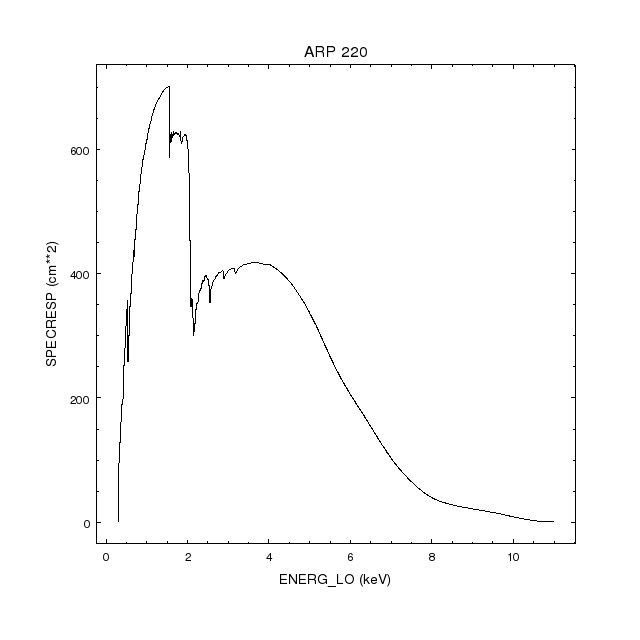

In [21]:
cat << EOM > c1.py
make_figure("simple_steps.arf[cols energ_lo,specresp]","histogram")
print_window("arf.src.png", "export.clobber=True")
quit()
EOM

chips -b c1.py
display < arf.src.png

In [22]:
pset mkwarf infile="simple_steps_bkg_tdet.fits[wmap]"
pset mkwarf outfile=simple_steps_bkg.arf
pset mkwarf weightfile=simple_steps_bkg.wfef
mkwarf mode=h clob+


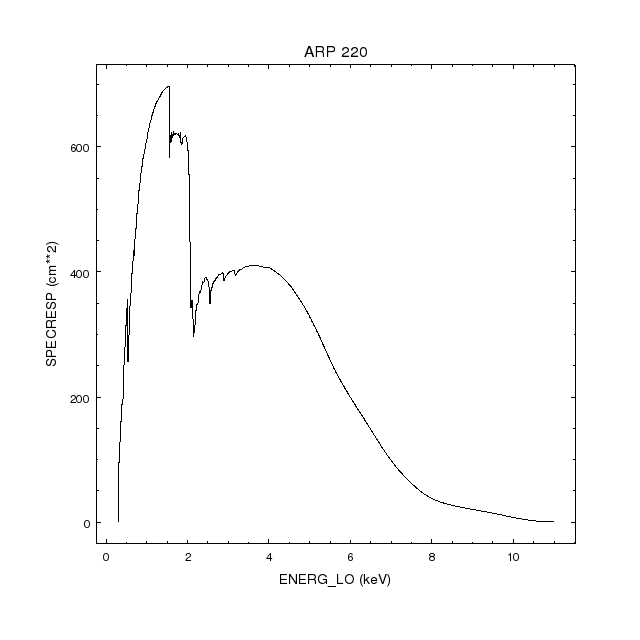

In [23]:
cat << EOM > c1.py
make_figure("simple_steps_bkg.arf[cols energ_lo,specresp]","histogram")
print_window("arf.bkg.png", "export.clobber=True")
quit()
EOM

chips -b c1.py
display < arf.bkg.png

### RMF


#### mkacisrmf

In [24]:
pset mkacisrmf infile=CALDB
pset mkacisrmf outfile=simple_steps_mkacisrmf.rmf
pset mkacisrmf energy=0.3:11.0:0.01
pset mkacisrmf channel=1:1024:1
pset mkacisrmf wmap="simple_steps.pi[WMAP]"
mkacisrmf mode=h clob+



Total 18 regions to be processed:
    1> reg# 1263  processed
    2> reg# 1264  processed
    3> reg# 1265  processed
    4> reg# 1266  processed
    5> reg# 1294  processed
    6> reg# 1295  processed
    7> reg# 1296  processed
    8> reg# 1297  processed
    9> reg# 1298  processed
   10> reg# 1326  processed
   11> reg# 1327  processed
   12> reg# 1328  processed
   13> reg# 1329  processed
   14> reg# 1330  processed
   15> reg# 1359  processed
   16> reg# 1360  processed
   17> reg# 1361  processed
   18> reg# 1391  processed



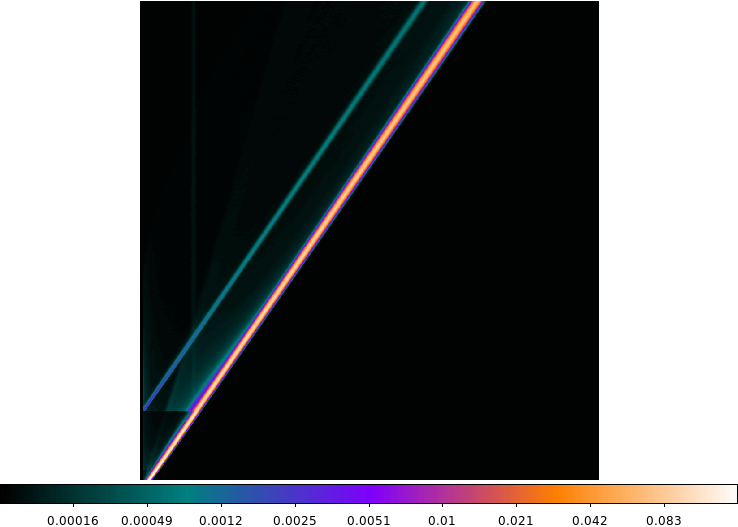

In [25]:
rmfimg simple_steps_mkacisrmf.rmf simple_steps_mkacisrmf.img clob+
ds9 simple_steps_mkacisrmf.img -scale log -zoom to fit \
  -cmap load $ASCDS_INSTALL/contrib/data/icool.lut \
  -saveimage png rmf.src.png -quit
display < rmf.src.png

In [26]:
pset mkacisrmf outfile=simple_steps_bkg_mkacisrmf.rmf
pset mkacisrmf wmap="simple_steps_bkg.pi[WMAP]"
mkacisrmf mode=h clob+




Total 17 regions to be processed:
    1> reg# 1393  processed
    2> reg# 1394  processed
    3> reg# 1395  processed
    4> reg# 1424  processed
    5> reg# 1425  processed
    6> reg# 1426  processed
    7> reg# 1427  processed
    8> reg# 1456  processed
    9> reg# 1457  processed
   10> reg# 1458  processed
   11> reg# 1459  processed
   12> reg# 1488  processed
   13> reg# 1489  processed
   14> reg# 1490  processed
   15> reg# 1491  processed
   16> reg# 1521  processed
   17> reg# 1522  processed



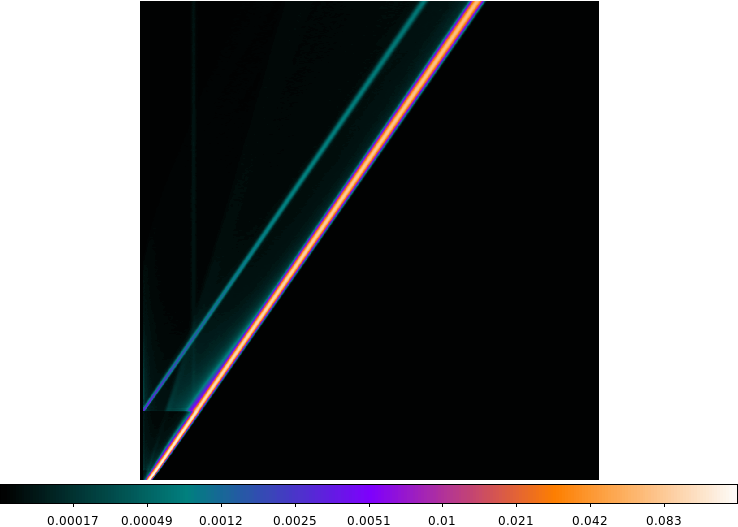

In [27]:
rmfimg simple_steps_bkg_mkacisrmf.rmf simple_steps_bkg_mkacisrmf.img clob+
ds9 simple_steps_bkg_mkacisrmf.img -scale log -zoom to fit \
  -cmap load $ASCDS_INSTALL/contrib/data/icool.lut \
  -saveimage png rmf.bkg.png -quit
display < rmf.bkg.png

#### Using mkrmf

In [28]:
pset mkrmf infile=CALDB
pset mkrmf outfile=simple_steps_mkrmf.rmf
pset mkrmf axis1="energy=0:1"
pset mkrmf axis2="pi=1:1024:1"
pset mkrmf weights=simple_steps.wfef
mkrmf mode=h clob+

In [29]:
pset mkrmf outfile=simple_steps_bkg_mkrmf.rmf
pset mkrmf weights=simple_steps_bkg.wfef
mkrmf mode=h clob+

### Group

In [30]:
pset dmgroup infile=simple_steps.pi
pset dmgroup outfile=simple_steps_grp.pi
pset dmgroup grouptype=NUM_CTS 
pset dmgroup grouptypeval=15
pset dmgroup xcolumn=channel
pset dmgroup ycolumn=counts
dmgroup mode=h clob+

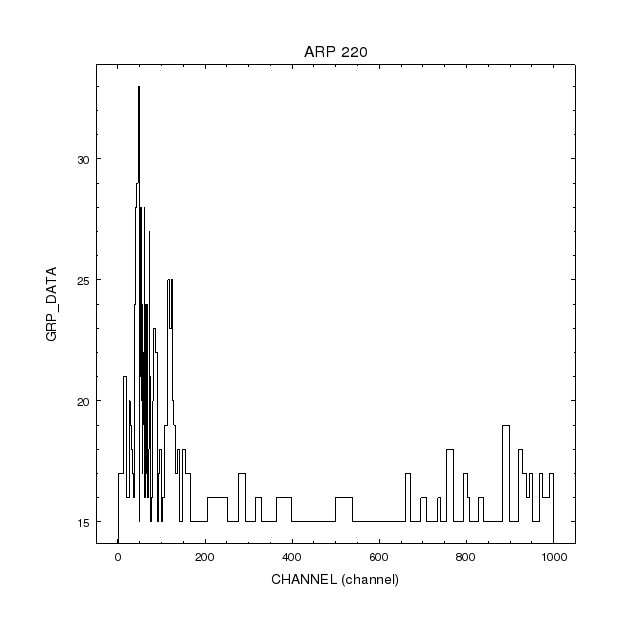

In [31]:
cat << EOM > c2.py
make_figure("simple_steps_grp.pi[channel=1:1000][cols channel,grp_data]", "histogram")
print_window("pha_grp.src.png","export.clobber=True")
quit()
EOM

chips -b c2.py
display < pha_grp.src.png 


### Update Headers


In [32]:
pset dmhedit operation=add filelist="" mode=h

dmhedit simple_steps.pi key=BACKFILE value=simple_steps_bkg.pi
dmhedit simple_steps.pi key=RESPFILE value=simple_steps_mkacisrmf.rmf
dmhedit simple_steps.pi key=ANCRFILE value=simple_steps_corr.arf

dmhedit simple_steps_grp.pi key=BACKFILE value=simple_steps_bkg.pi
dmhedit simple_steps_grp.pi key=RESPFILE value=simple_steps_mkacisrmf.rmf
dmhedit simple_steps_grp.pi key=ANCRFILE value=simple_steps.arf

In [33]:
dmhedit simple_steps_bkg.pi operation=add key=RESPFILE value=simple_steps_bkg_mkacisrmf.rmf
dmhedit simple_steps_bkg.pi operation=add key=ANCRFILE value=simple_steps_bkg.arf

read RMF file simple_steps_mkacisrmf.rmf
read ARF (background) file simple_steps_bkg.arf
read RMF (background) file simple_steps_bkg_mkacisrmf.rmf
read background file simple_steps_bkg.pi


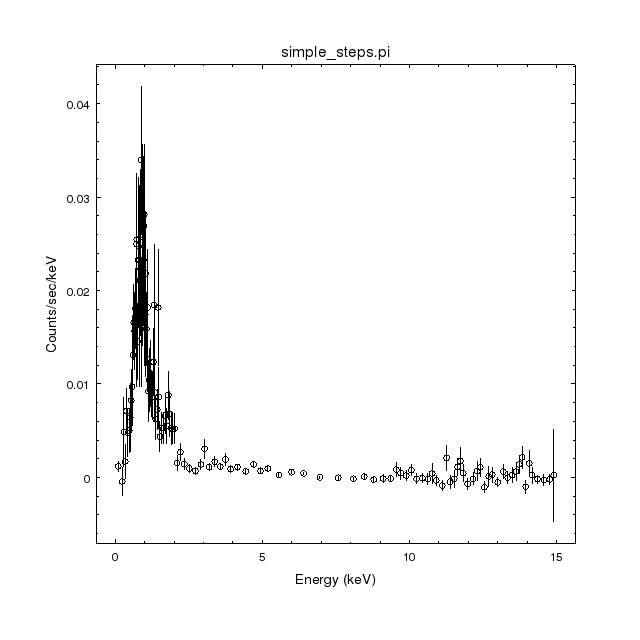

In [34]:
cat << EOM > s1.py
load_data("simple_steps.pi")
group_counts(15)
subtract()
plot_data()
print_window("sherpa.png","export.clobber=True")
quit()
EOM

sherpa -b s1.py
display < sherpa.png

---

## Extracting multiple spectra

In [35]:
/bin/rm -rf 1842 1843
download_chandra_obsid 1842,1843 
chandra_repro 1842,1843 out= 


  Type     Format      Size  0........H.........1  Download Time Average Rate
  ---------------------------------------------------------------------------
  readme   ascii      11 Kb  ####################          < 1 s  1817.9 kb/s
  oif      fits       23 Kb  ####################          < 1 s  3236.9 kb/s
  vv       pdf        44 Kb  ####################          < 1 s  5911.1 kb/s
  cntr_img fits      230 Kb  ####################          < 1 s  16432.2 kb/s
  cntr_img jpg       910 Kb  ####################          < 1 s  28870.3 kb/s
  evt2     fits       19 Mb  ####################          < 1 s  61161.2 kb/s
  full_img fits       91 Kb  ####################          < 1 s  9564.6 kb/s
  full_img jpg        74 Kb  ####################          < 1 s  8018.6 kb/s
  bpix     fits       12 Kb  ####################          < 1 s  1894.1 kb/s
  fov      fits        6 Kb  ####################          < 1 s  934.0 kb/s
  eph1     fits      281 Kb  ####################          < 

In [36]:
/bin/rm -rf multi_reproj
reproject_obs 1842,1843 multi_reproj/ clob+

Running reproject_obs
Version: 27 October 2016

Found 1842/repro/acisf01842_repro_evt2.fits
Found 1843/repro/acisf01843_repro_evt2.fits
Verifying 2 observations.
Calculating new tangent point.
New tangent point: RA=18h 32m 21.696s Dec=-10d 34' 41.484"

Observations to be reprojected:

  Obsid  Obs Date   Exp    DETNAM     SIM_Z    FP   Sepn   PA  
                   (ks)                (mm)    (K)   (')  (deg)
---------------------------------------------------------------
1 1843  2000-09-02   7.9 ACIS-012367 -245.857 153.4   2.6   -79
2 1842  2000-09-02   7.4 ACIS-012367 -231.239 153.4   2.6  +101

Running tasks in parallel with 4 processors.
Reprojecting 2 event files to a common tangent point.
Merging reprojected events files to multi_reproj/merged_evt.fits

The following files were created:

The reprojected event files:
     multi_reproj/1843_reproj_evt.fits
     multi_reproj/1842_reproj_evt.fits

The merged event file:
     multi_reproj/merged_evt.fits

   should not be used to cr

### Regions

In [37]:
cat << EOM > 1842_src.reg
# Region file format: CIAO version 1.0
circle(1943.3,4164.2,102)
EOM

cat << EOM > 1843_src.reg
# Region file format: CIAO version 1.0
circle(1943.3,4164.2,135)
EOM

cat << EOM > 1842_bg.reg
# Region file format: CIAO version 1.0
circle(2259.3,4072.3,100)
EOM

cat << EOM > 1843_bg.reg
# Region file format: CIAO version 1.0
circle(2361.5,4104.8,140)
EOM


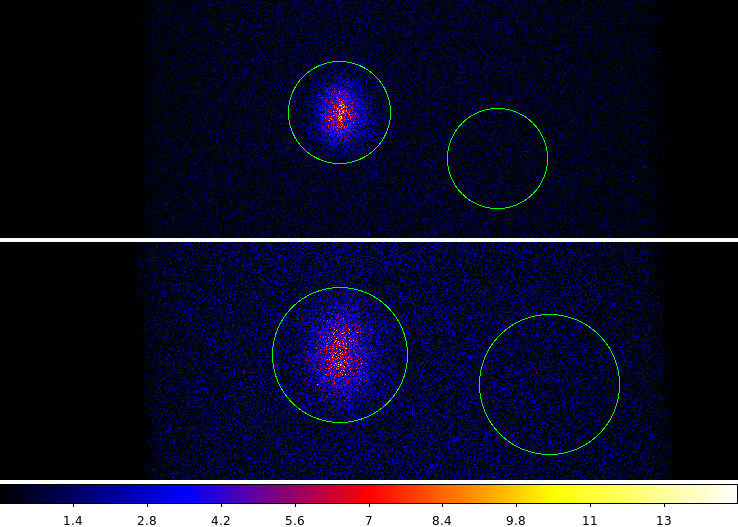

In [38]:
ds9 multi_reproj/1842_reproj_evt.fits -bin filter 'energy=500:7000' \
  -bin about 2000 4150 -bin factor 2 -cmap b -region 1842_src.reg -region 1842_bg.reg \
  multi_reproj/1843_reproj_evt.fits -bin filter 'energy=500:7000' \
  -bin about 2000 4150 -bin factor 2 -cmap b -region 1843_src.reg \
  -region 1843_bg.reg -tile row \
  -saveimage png multi_obi.png -quit

display < multi_obi.png

In [39]:
cat << EOM > multi_src.lis
multi_reproj/1842_reproj_evt.fits[sky=region(1842_src.reg)]
multi_reproj/1843_reproj_evt.fits[sky=region(1843_src.reg)]
EOM


In [40]:
cat << EOM > multi_bg.lis
multi_reproj/1842_reproj_evt.fits[sky=region(1842_bg.reg)]
multi_reproj/1843_reproj_evt.fits[sky=region(1843_bg.reg)]
EOM

In [41]:
/bin/rm -rf spec
mkdir -p spec
pset specextract infile=@-multi_src.lis
pset specextract outroot=spec/1842,spec/1843
pset specextract bkgfile=@-multi_bg.lis
specextract mode=h clob+


Running specextract
Version: 30 November 2016

Checking for blank sky background files...
Using event file multi_reproj/1842_reproj_evt.fits[sky=region(1842_src.reg)]

Aspect solution file multi_reproj/1842.asol found.

Bad-pixel file multi_reproj/1842.bpix found.

Mask file multi_reproj/1842.mask found.

Using event file multi_reproj/1843_reproj_evt.fits[sky=region(1843_src.reg)]

Aspect solution file multi_reproj/1843.asol found.

Bad-pixel file multi_reproj/1843.bpix found.

Mask file multi_reproj/1843.mask found.

Setting bad pixel file [1 of 2]

Extracting src spectra [1 of 2]

Creating src ARF [1 of 2]

Creating src RMF [1 of 2]

Using mkacisrmf...

Grouping src spectrum [1 of 2]

Updating header of spec/1842.pi with RESPFILE and ANCRFILE keywords.

Updating header of spec/1842_grp.pi with RESPFILE and ANCRFILE keywords.

Setting bad pixel file [2 of 2]

Extracting src spectra [2 of 2]

Creating src ARF [2 of 2]

Creating src RMF [2 of 2]

Using mkacisrmf...

Grouping src spectru

In [42]:
combine_spectra spec/1842.pi,spec/1843.pi spec/combo clob+

Prepared to combine 2 spectra

source PHA: spec/1842.pi
       ARF: spec/1842.arf
       RMF: spec/1842.rmf
    background PHA: spec/1842_bkg.pi
               ARF: spec/1842_bkg.arf
               RMF: spec/1842_bkg.rmf
source PHA: spec/1843.pi
       ARF: spec/1843.arf
       RMF: spec/1843.rmf
    background PHA: spec/1843_bkg.pi
               ARF: spec/1843_bkg.arf
               RMF: spec/1843_bkg.rmf

The following files were created:
  spec/combo_src.pi
  spec/combo_bkg.pi
  spec/combo_src.arf
  spec/combo_bkg.arf
  spec/combo_src.rmf
  spec/combo_bkg.rmf


read ARF file spec/combo_src.arf
read RMF file spec/combo_src.rmf
read ARF (background) file spec/combo_bkg.arf
read RMF (background) file spec/combo_bkg.rmf
read background file spec/combo_bkg.pi


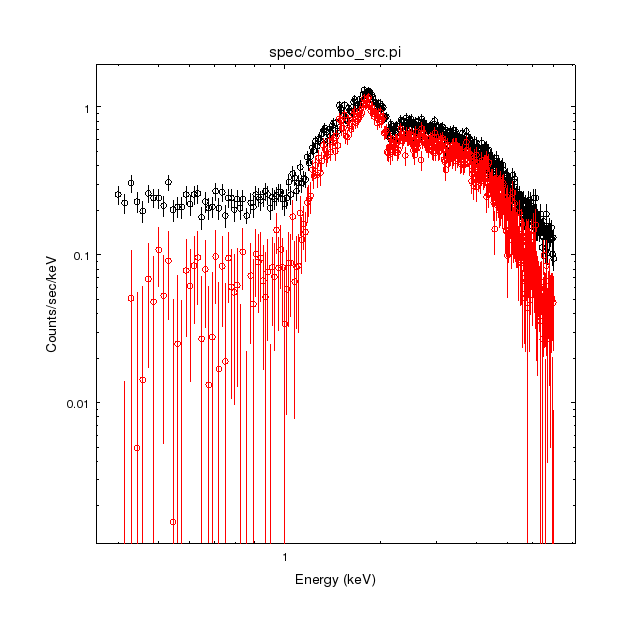

In [43]:
cat << EOM > s2.py
load_data("spec/combo_src.pi")
notice(0.3, 7)
group_counts(40)
plot_data()
log_scale()
subtract()
plot_data(overplot=True)
set_curve(['*.color', 'red'])
print_window("multi_obi_src.png","export.clobber=True")
quit()
EOM

sherpa -b s2.py
display < multi_obi_src.png



# Cleanup


In [ ]:
mv -fv multi_reproj/merged_evt.fits ./
mv -fv spec/* ./
/bin/rm -rf spec multi_reproj 1842 1843 869
